# Aprendizaje Automático - Clase 4
## Desarrollo Actividad 1 - Regresión Líneal

Este notebook trabaja con el dataset oficial **Forty Soybean Cultivars from Subsequent Harvests** (UCI, dataset 913).

Mediante el uso de Regresión lineal, vamos a prdecir la **Variable objetivo:** `GY` → rendimiento de grano (kg/ha).

> Importante: UCI recomienda que un mismo cultivar no quede simultáneamente en entrenamiento y prueba. Por eso se utiliza una división por grupos (`Cultivar`) en lugar de una división aleatoria fila por fila.

# Importamos las librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (classification_report, confusion_matrix, mean_absolute_error,
    mean_squared_error, r2_score)

# Configuración para gráficos más nítidos
plt.rcParams["figure.figsize"] = (8, 5)
plt.style.use("ggplot")

# Cargamos el archivo CSV

In [2]:
# Carga del dataset
df = pd.read_csv("soja.csv")

# Inspección del dataset

In [3]:
print("Visualización de las primeras filas:")
display(df.head())
print("\nCantidad de filas y columnas:", df.shape)
print("\nInformación general:")
print(df.info())
print("\nDescripción estadística:")
df.describe()
#display(df.describe(include='all').T)

Visualización de las primeras filas:


,Season,Cultivar,Repetition,PH,IFP,NLP,NGP,NGL,NS,MHG,GY
0,1,NEO 760 CE,1,58.80,15.20,98.2,177.80,1.81,5.2,152.20,3232.82
1,1,NEO 760 CE,2,58.60,13.40,102.0,195.00,1.85,7.2,141.69,3517.36
2,1,NEO 760 CE,3,63.40,17.20,100.4,203.00,2.02,6.8,148.81,3391.46
3,1,NEO 760 CE,4,60.27,15.27,100.2,191.93,1.89,6.4,148.50,3312.58
4,1,MANU IPRO,1,81.20,18.00,98.8,173.00,1.75,7.4,145.59,3230.99



Cantidad de filas y columnas: (320, 11)

Información general:
<class 'pandas.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Season      320 non-null    int64  
 1   Cultivar    320 non-null    str    
 2   Repetition  320 non-null    int64  
 3   PH          320 non-null    float64
 4   IFP         320 non-null    float64
 5   NLP         320 non-null    float64
 6   NGP         320 non-null    float64
 7   NGL         320 non-null    float64
 8   NS          320 non-null    float64
 9   MHG         320 non-null    float64
 10  GY          320 non-null    float64
dtypes: float64(8), int64(2), str(1)
memory usage: 31.8 KB
None

Descripción estadística:


,Season,Repetition,PH,IFP,NLP,NGP,NGL,NS,MHG,GY
count,320.000000,320.000000,320.000000,320.0000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000
mean,1.500000,2.500000,68.386781,15.4650,59.088313,135.085844,2.290844,4.071656,168.322313,3418.553794
std,0.500783,1.119785,8.958194,3.0243,20.068187,60.494529,0.840116,1.474531,19.625566,503.003602
min,1.000000,1.000000,47.600000,7.2000,20.200000,47.800000,0.940000,0.400000,127.060000,1538.230000
25%,1.000000,1.750000,62.950000,13.6000,44.350000,95.052500,2.000000,3.000000,153.845000,3126.611552
50%,1.500000,2.500000,67.200000,15.6000,54.500000,123.000000,2.280000,3.800000,166.150000,3397.276724
75%,2.000000,3.250000,74.347500,17.3300,71.220000,161.350000,2.480000,5.000000,183.182500,3708.262931
max,2.000000,4.000000,94.800000,26.4000,123.000000,683.400000,14.860000,9.000000,216.000000,4930.000000


### Diccionario de variables

| Variable | Descripción |
|---|---|
| `Season` | Temporada experimental (1 o 2) |
| `Cultivar` | Variedad de soja |
| `Repetition` | Repetición experimental (1 a 4) |
| `PH` | Altura de la planta, en cm |
| `IFP` | Altura de inserción de la primera vaina, en cm |
| `NLP` | Número de tallos |
| `NGP` | Número de vainas por planta |
| `NGL` | Número de granos por planta |
| `NS` | Número de granos por vaina |
| `MHG` | Peso de mil semillas, en gramos |
| `GY` | Rendimiento de grano, en kg/ha; **variable objetivo** |

# Detectar valores faltantes y filas duplicadas

In [4]:
print("\nCantidad de valores faltantes por columna:")
print(df.isna().sum())

print('\nFilas duplicadas:', df.duplicated().sum())


Cantidad de valores faltantes por columna:
Season        0
Cultivar      0
Repetition    0
PH            0
IFP           0
NLP           0
NGP           0
NGL           0
NS            0
MHG           0
GY            0
dtype: int64

Filas duplicadas: 0


# Distribución de la variable de estudio ´GY´

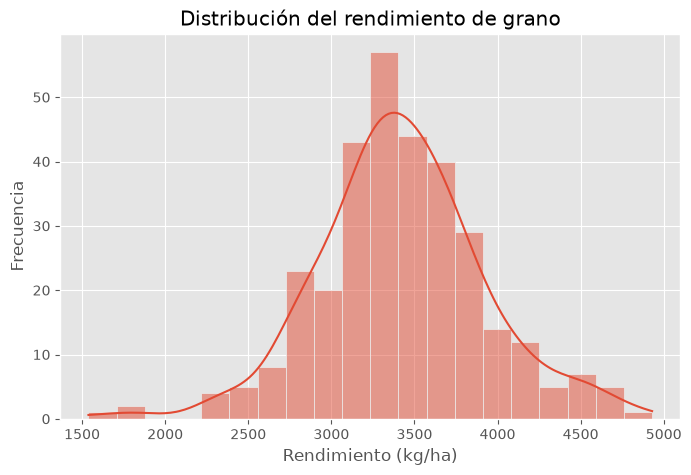

In [5]:
sns.histplot(df['GY'], kde=True)
plt.title('Distribución del rendimiento de grano')
plt.xlabel('Rendimiento (kg/ha)')
plt.ylabel('Frecuencia')
plt.show()

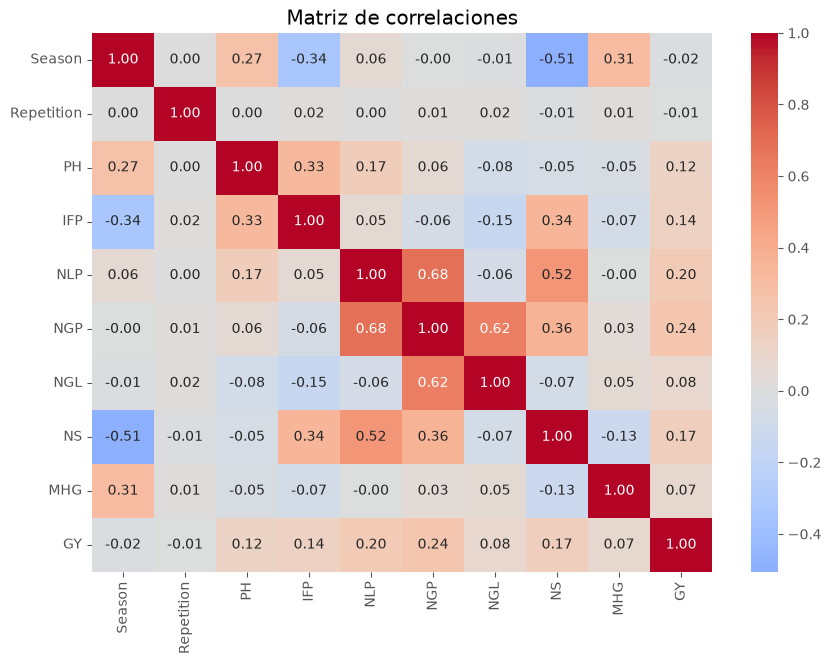

Correlación con la variable objetivo (GY):


GY            1.000000
NGP           0.238883
NLP           0.198741
NS            0.167022
IFP           0.139090
PH            0.123281
NGL           0.077404
MHG           0.074552
Repetition   -0.005697
Season       -0.019710
Name: GY, dtype: float64

In [6]:
numericas = df.select_dtypes(include=np.number)
corr = numericas.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlaciones')
plt.show()

print('Correlación con la variable objetivo (GY):')
display(corr['GY'].sort_values(ascending=False))

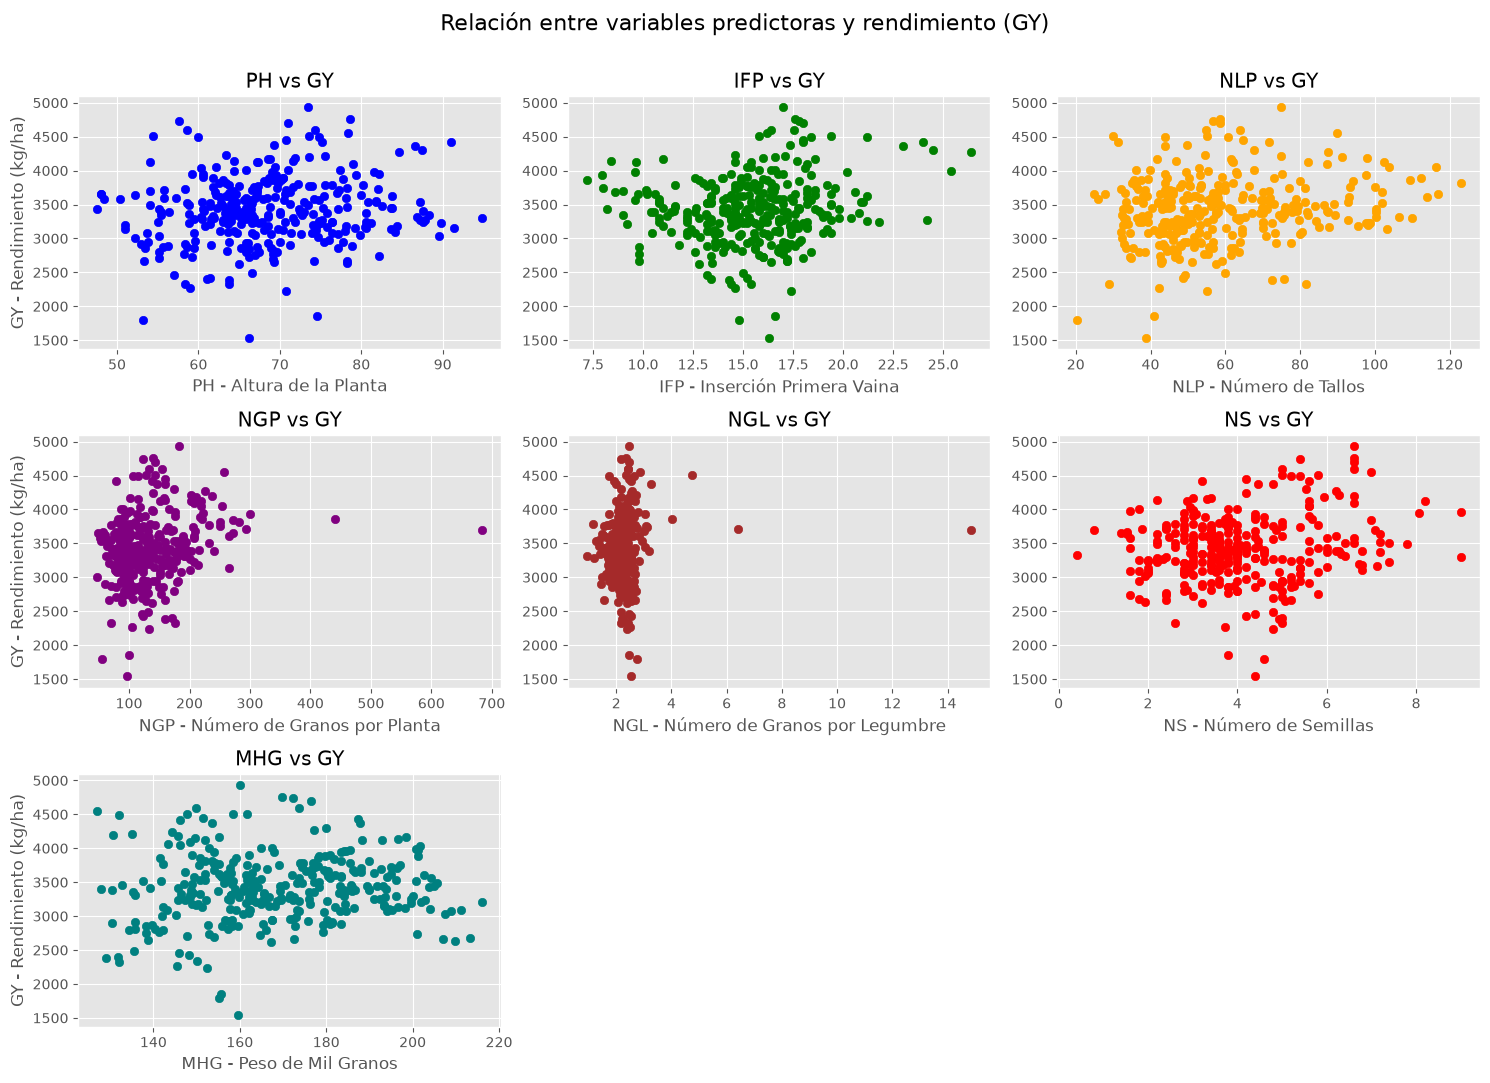

In [7]:
# Variables predictoras
predictoras_graficas = ['PH', 'IFP', 'NLP', 'NGP', 'NGL', 'NS', 'MHG']

# Crear figura con 3 filas y 3 columnas
fig, axs = plt.subplots(3, 3, figsize=(15, 11))

# Convertir la matriz de ejes en una lista
axs = axs.flatten()

# PH
axs[0].scatter(df['PH'], df['GY'], color='blue')
axs[0].set_title("PH vs GY")
axs[0].set_xlabel("PH - Altura de la Planta")
axs[0].set_ylabel("GY - Rendimiento (kg/ha)")

# IFP
axs[1].scatter(df['IFP'], df['GY'], color='green')
axs[1].set_title("IFP vs GY")
axs[1].set_xlabel("IFP - Inserción Primera Vaina")
#axs[1].set_ylabel("GY - Rendimiento (kg/ha)")

# NLP
axs[2].scatter(df['NLP'], df['GY'], color='orange')
axs[2].set_title("NLP vs GY")
axs[2].set_xlabel("NLP - Número de Tallos")
#axs[2].set_ylabel("GY - Rendimiento (kg/ha)")

# NGP
axs[3].scatter(df['NGP'], df['GY'], color='purple')
axs[3].set_title("NGP vs GY")
axs[3].set_xlabel("NGP - Número de Granos por Planta")
axs[3].set_ylabel("GY - Rendimiento (kg/ha)")

# NGL
axs[4].scatter(df['NGL'], df['GY'], color='brown')
axs[4].set_title("NGL vs GY")
axs[4].set_xlabel("NGL - Número de Granos por Legumbre")
#axs[4].set_ylabel("GY - Rendimiento (kg/ha)")

# NS
axs[5].scatter(df['NS'], df['GY'], color='red')
axs[5].set_title("NS vs GY")
axs[5].set_xlabel("NS - Número de Semillas")
#axs[5].set_ylabel("GY - Rendimiento (kg/ha)")

# MHG
axs[6].scatter(df['MHG'], df['GY'], color='teal')
axs[6].set_title("MHG vs GY")
axs[6].set_xlabel("MHG - Peso de Mil Granos")
axs[6].set_ylabel("GY - Rendimiento (kg/ha)")

# Ocultar los dos espacios que quedan vacíos
axs[7].set_visible(False)
axs[8].set_visible(False)

# Título general
plt.suptitle("Relación entre variables predictoras y rendimiento (GY)\n",
             fontsize=16)

# Ajustar espacios
plt.tight_layout()

# Mostrar
plt.show()

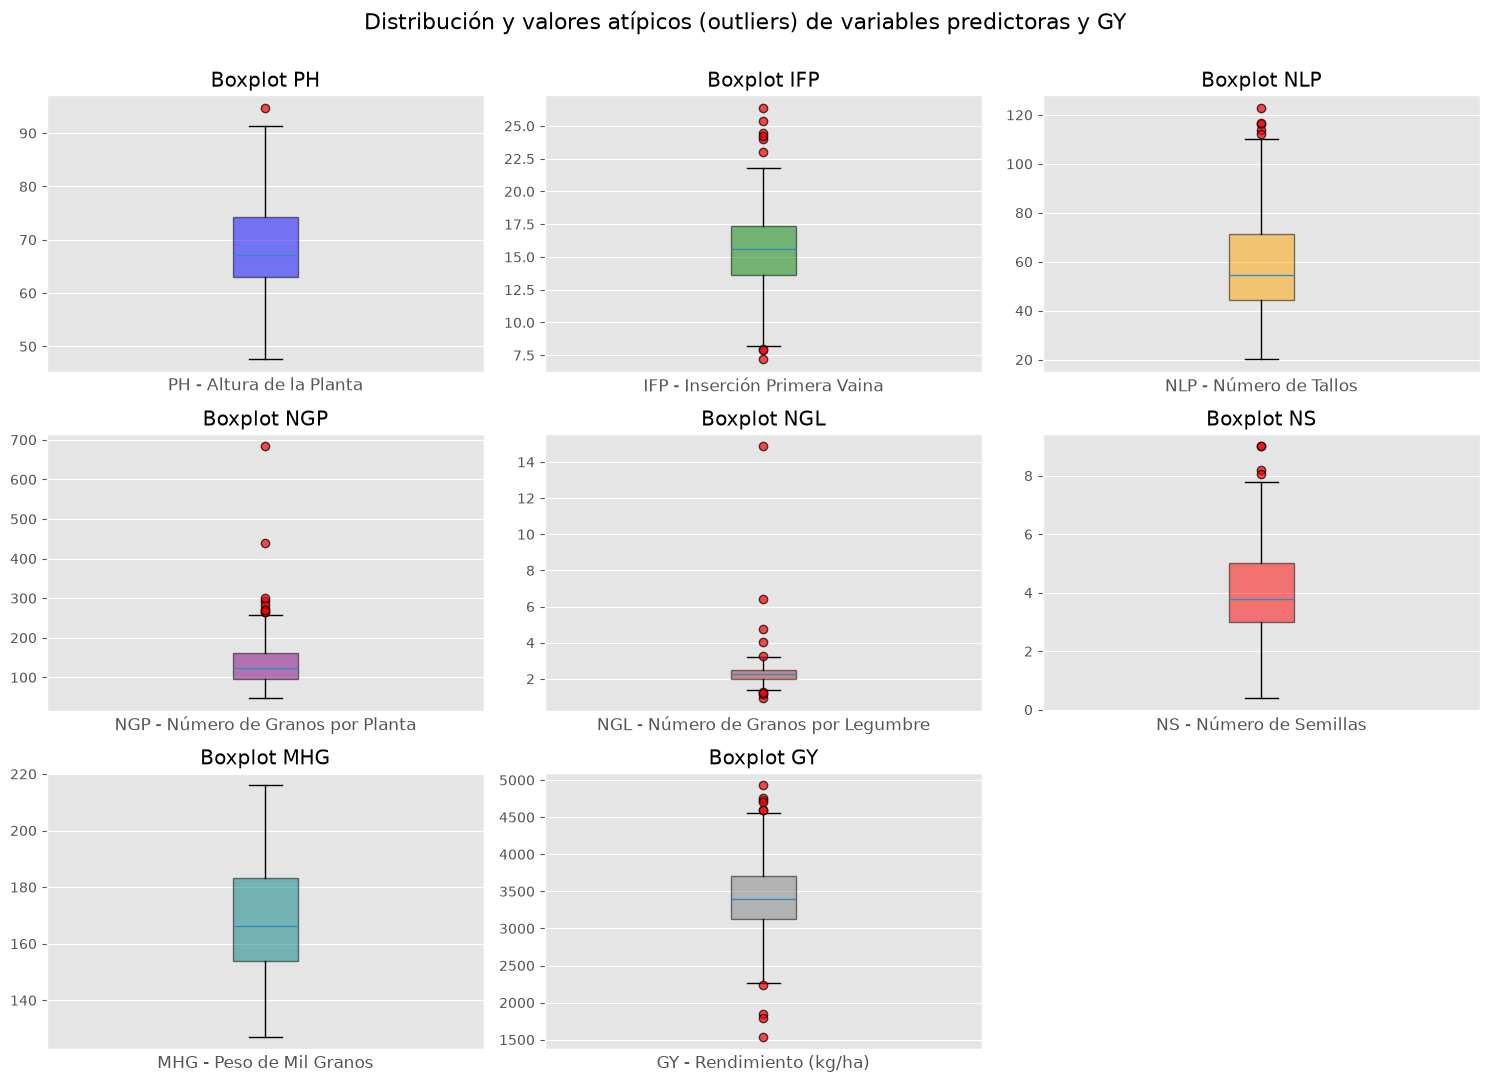

In [18]:
# Variables a analizar (incluyo GY para ver también los outliers de la variable respuesta)
variables_boxplot = ['PH', 'IFP', 'NLP', 'NGP', 'NGL', 'NS', 'MHG', 'GY']

# Crear figura con 3 filas y 3 columnas
fig, axs = plt.subplots(3, 3, figsize=(15, 11))
axs = axs.flatten()

# Diccionario con nombres descriptivos y colores (mismo criterio que tu gráfico original)
info_vars = {
    'PH':  {'nombre': 'PH - Altura de la Planta',            'color': 'blue'},
    'IFP': {'nombre': 'IFP - Inserción Primera Vaina',       'color': 'green'},
    'NLP': {'nombre': 'NLP - Número de Tallos',              'color': 'orange'},
    'NGP': {'nombre': 'NGP - Número de Granos por Planta',   'color': 'purple'},
    'NGL': {'nombre': 'NGL - Número de Granos por Legumbre', 'color': 'brown'},
    'NS':  {'nombre': 'NS - Número de Semillas',             'color': 'red'},
    'MHG': {'nombre': 'MHG - Peso de Mil Granos',            'color': 'teal'},
    'GY':  {'nombre': 'GY - Rendimiento (kg/ha)',            'color': 'gray'},
}

# Generar un boxplot por variable
for i, var in enumerate(variables_boxplot):
    bp = axs[i].boxplot(
        df[var].dropna(),
        orientation='vertical',
        patch_artist=True,
        flierprops=dict(marker='o', markerfacecolor='red', markersize=6, 
                         markeredgecolor='black', alpha=0.7)  # resalta outliers en rojo
    )
    # Color de relleno de la caja
    bp['boxes'][0].set_facecolor(info_vars[var]['color'])
    bp['boxes'][0].set_alpha(0.5)

    axs[i].set_title(f"Boxplot {var}")
    axs[i].set_xlabel(info_vars[var]['nombre'])
    axs[i].set_xticks([])  # oculta el "1" que pone matplotlib por defecto en el eje X

# Ocultar el espacio vacío (con 8 variables sobra 1 subplot de los 9)
axs[8].set_visible(False)

# Título general
plt.suptitle("Distribución y valores atípicos (outliers) de variables predictoras y GY\n",
             fontsize=16)

plt.tight_layout()
plt.show()

## Modelo de Regresión Lineal Múltiple

Se excluyen `repeticion` y `temporada` como predictores principales del modelo base. `cultivar` se incorpora como variable categórica mediante one-hot encoding. La separación entrenamiento/prueba se realiza por cultivar para evitar que una misma variedad aparezca en ambos conjuntos.

In [8]:
# Variables predictoras y target
X = df.drop("GY", axis=1)
y = df["GY"]

# Variables numéricas y categóricas
columnas_numericas = [
    'Season', 'Repetition', 'PH', 'IFP',
    'NLP', 'NGP', 'NGL', 'NS', 'MHG'
]

columnas_categoricas = ['Cultivar']

# Preprocesamiento
preprocesamiento = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), columnas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), columnas_categoricas)
    ]
)

# Dividir los datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Conjunto de entrenamiento: {X_train.shape[0]}")
print(f"Conjunto de prueba: {X_test.shape[0]}")

Conjunto de entrenamiento: 256
Conjunto de prueba: 64


In [9]:
# Creamos el Modelo de Regresión
modelo = Pipeline([
    ('preprocesamiento', preprocesamiento),
    ('regresion', LinearRegression())
])
# Entrenamos el modelo con los datos de entrenamiento
modelo.fit(X_train, y_train)

# Realizamos predicciones con los datos de prueba
y_pred = modelo.predict(X_test)

resultados = pd.DataFrame({
    'real': y_test.values,
    'predicho': y_pred
})

display(resultados.head(15))

,real,predicho
0,3357.701149,3188.378339
1,3766.764368,3752.876079
2,3508.550000,3074.178793
3,4211.030000,4061.566250
4,3602.340000,3799.169272
5,3000.920000,2804.989228
6,2737.528736,2967.620698
7,3182.670000,3285.526819
8,2733.137931,2141.121653
9,3279.563218,3877.690156


In [10]:
from sklearn.metrics import explained_variance_score
# Métricas
print("\nEvaluación del modelo (Regresión Múltiple - Datos de Preuba):")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.3f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")
print(f"R²: {r2_score(y_test, y_pred):.3f}")
print(f"Varianza explicada: {explained_variance_score(y_test, y_pred):.3f}")

# Acceder al modelo de regresión dentro del Pipeline
regresion = modelo.named_steps['regresion']

print("\nIntercepto:", regresion.intercept_)
print("\nCoeficientes:\n", regresion.coef_)

# Resultados en tabla
preprocesamiento = modelo.named_steps['preprocesamiento']
nombres_variables = preprocesamiento.get_feature_names_out()

resultados = pd.DataFrame({
    "Variable": nombres_variables,
    "Coeficiente": regresion.coef_
})

resultados = resultados.sort_values(
    by="Coeficiente",
    ascending=False
)

print("\nCoeficientes por variable:")
display(resultados)


Evaluación del modelo (Regresión Múltiple - Datos de Preuba):
MAE: 275.567
MSE: 123572.017
RMSE: 351.528
R²: 0.523
Varianza explicada: 0.526

Intercepto: 3417.4229146814455

Coeficientes:
 [ 1.21760835e+01 -6.09248460e-01  5.65698877e+01  9.84984880e+01
 -1.45465575e+02  1.88760773e+02 -8.11970249e+01  8.38523466e+01
  1.54059476e+02  2.75338184e+01  2.24767310e+02  1.58457303e+02
  8.40434757e+01 -5.25155223e+02  5.08227855e+02 -1.07729230e+03
 -5.51067698e+02  2.76705824e+02  4.20153387e+02 -2.02187690e+02
 -5.98490659e+02  8.31167039e+01 -2.19680073e+02  7.43627633e+01
  5.09267268e+02  6.30334601e+02 -3.13279874e+02  4.16315817e+02
 -3.06902659e+01 -2.33594335e+02  2.78777156e+02 -2.75475338e+02
  8.77854701e+01 -3.91586263e+02 -1.00621168e+02 -2.44764109e+01
  5.21751267e+01 -1.57585549e+02  7.73085999e+02  3.95240914e+02
 -1.32359705e+01 -3.66705516e+02  7.52423702e+01 -6.77697623e+02
  1.78870999e+01  1.92525485e+02  5.34840642e+02 -2.99777273e+02
  2.37752842e+02]

Coeficiente

,Variable,Coeficiente
38,cat__Cultivar_MONSOY 8330I2X,773.085999
25,cat__Cultivar_FORTALEZA IPRO,630.334601
46,cat__Cultivar_SUZY IPRO,534.840642
24,cat__Cultivar_FORTALECE L090183 RR,509.267268
14,cat__Cultivar_83IX84RSF I2X,508.227855
18,cat__Cultivar_ADAPTA LTT 8402 IPRO,420.153387
27,cat__Cultivar_FTR 3190 IPRO,416.315817
39,cat__Cultivar_MONSOY M8606I2X,395.240914
30,cat__Cultivar_FTR 4288 IPRO,278.777156
17,cat__Cultivar_98R30 CE,276.705824


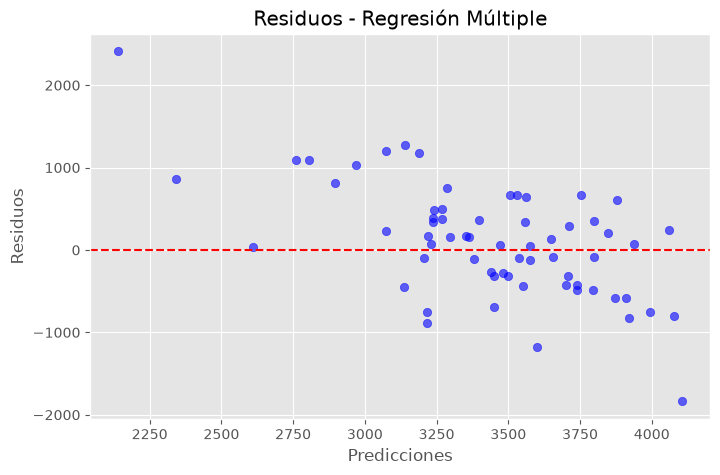

In [16]:
residuos = y_test - y_pred

plt.scatter(y_pred, residuos, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Residuos - Regresión Múltiple")
plt.show()

,real,predicho
0,4368.41,3970.273458
1,4425.03,3680.685458
2,4270.16,3842.291591
3,4299.17,3807.047939
4,3716.41,3286.955930
5,3899.38,3215.268951
6,3993.56,3699.087130
7,4035.31,3453.959292
8,4552.40,3373.970216
9,4488.97,3323.778541


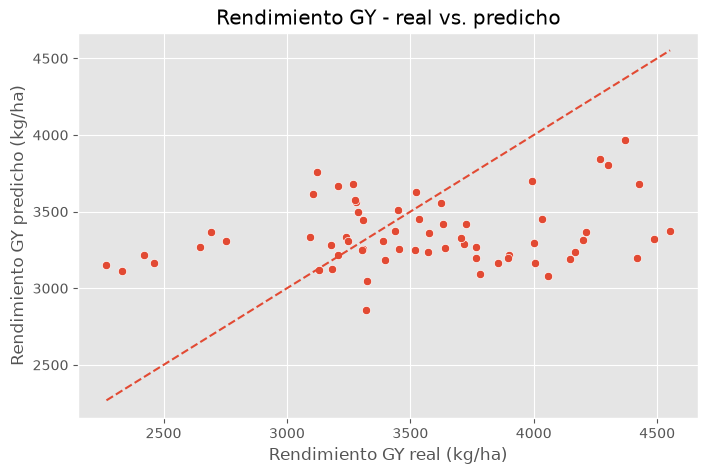

In [15]:
resultados = pd.DataFrame({
    'real': y_test.values,
    'predicho': predicciones
})

display(resultados.head(15))

sns.scatterplot(x=resultados['real'], y=resultados['predicho'])
limites = [resultados[['real', 'predicho']].min().min(), resultados[['real', 'predicho']].max().max()]
plt.plot(limites, limites, linestyle='--')
plt.xlabel('Rendimiento GY real (kg/ha)')
plt.ylabel('Rendimiento GY predicho (kg/ha)')
plt.title('Rendimiento GY - real vs. predicho')
plt.show()

## Conclusión

La evaluación del modelo de Regresión Múltiple sobre los datos de prueba obtuvo un MAE de 275,567 y un RMSE de 351,528, indicando un error promedio considerable en las predicciones del rendimiento. El coeficiente de determinación R² fue de 0,523, por lo que el modelo explica aproximadamente el 52,3 % de la variabilidad observada en la variable GY. La varianza explicada fue de 0,526, equivalente al 52,6 %, resultado consistente con el R² obtenido. El modelo no tiene sesgo sistemático fuerte. La cercanía entre R² y varianza explicada (0.523 vs 0.526) es un punto positivo: el modelo no predice consistentemente por arriba o por abajo del promedio general, el error está más relacionado con falta de ajuste que con un sesgo direccional.

El modelo es un punto de partida razonable pero insuficiente para uso predictivo preciso. Es útil como aproximación gruesa del rendimiento esperado, pero no debería usarse para decisiones que requieran precisión en los extremos (muy alto o muy bajo rendimiento). Se recomienda explorar modelos no lineales (Random Forest, Gradient Boosting) y/o incorporar variables explicativas adicionales antes de considerar el modelo apto para producción o toma de decisiones críticas.